In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/PhiUSIIL_Phishing_URL_Dataset.csv') # pandas library reading the file
print(df.shape)
print(df.columns.tolist())

(235795, 56)
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [2]:
# Check the label values and class balance
print(df['label'].value_counts())
print()
print(df.shape)
print()
# Check for missing values
print(df.isnull().sum().sort_values(ascending=False).head(20))
print(df.dtypes)

label
1    134850
0    100945
Name: count, dtype: int64

(235795, 56)

FILENAME                 0
URL                      0
DomainTitleMatchScore    0
URLTitleMatchScore       0
HasFavicon               0
Robots                   0
IsResponsive             0
NoOfURLRedirect          0
NoOfSelfRedirect         0
HasDescription           0
NoOfPopup                0
NoOfiFrame               0
HasExternalFormSubmit    0
HasSocialNet             0
HasSubmitButton          0
HasHiddenFields          0
HasPasswordField         0
Bank                     0
Pay                      0
Crypto                   0
dtype: int64
FILENAME                          str
URL                               str
URLLength                       int64
Domain                            str
DomainLength                    int64
IsDomainIP                      int64
TLD                               str
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             floa

In [3]:
print(df[['URL','Domain','TLD','Title']].head(10))

                                  URL                      Domain  TLD  \
0    https://www.southbankmosaics.com    www.southbankmosaics.com  com   
1            https://www.uni-mainz.de            www.uni-mainz.de   de   
2      https://www.voicefmradio.co.uk      www.voicefmradio.co.uk   uk   
3         https://www.sfnmjournal.com         www.sfnmjournal.com  com   
4  https://www.rewildingargentina.org  www.rewildingargentina.org  org   
5     https://www.globalreporting.org     www.globalreporting.org  org   
6          https://www.saffronart.com          www.saffronart.com  com   
7          https://www.nerdscandy.com          www.nerdscandy.com  com   
8      https://www.hyderabadonline.in      www.hyderabadonline.in   in   
9                 https://www.aap.org                 www.aap.org  org   

                                               Title  
0  à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...  
1              johannes gutenberg-universitÃ¤t mainz  
2                   

In [4]:
df=df.drop(columns=['URL','Domain','TLD','Title'])
print(df.shape)
print(df.dtypes.value_counts())

(235795, 52)
int64      41
float64    10
str         1
Name: count, dtype: int64


In [5]:
print(df.select_dtypes(include='str').columns.tolist())

['FILENAME']


In [6]:
df = df.drop(columns=['FILENAME'])
print(df.shape)
print(df.dtypes.value_counts())

(235795, 51)
int64      41
float64    10
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())

URLLength                     0
DomainLength                  0
IsDomainIP                    0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavicon                    0
Robots                        0
IsResponsive                  0
NoOfURLRedirect               0
NoOfSelf

In [8]:
# Define classification
y = df['label']

# Define the features 
X = df.drop(columns=["label"])

In [9]:
from sklearn.model_selection import train_test_split

# split the data 80% training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=1)
print(X_train.shape)
print(X_test.shape)

(188636, 50)
(47159, 50)


In [10]:
# train the model
from sklearn.tree import DecisionTreeClassifier

# setting the max_depth to None, the nodes will expand until all leaves are pure ( overfitting )
phishing_url_model = DecisionTreeClassifier(random_state=1)

# fit the model
phishing_url_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [11]:
from sklearn.metrics import accuracy_score
# test the model on the testing data
predictions = phishing_url_model.predict(X_test)

accuracy_score(y_test, predictions)

predictions_training_set = phishing_url_model.predict(X_train)
accuracy_score(y_train, predictions_training_set)

print("Training accuracy:", accuracy_score(y_train, predictions_training_set))
print("Test accuracy:", accuracy_score(y_test, predictions))

Training accuracy: 1.0
Test accuracy: 1.0


URLSimilarityIndex    0.986737
LineOfCode            0.012917
IsHTTPS               0.000303
NoOfSubDomain         0.000043
URLLength             0.000000
HasSubmitButton       0.000000
IsResponsive          0.000000
NoOfURLRedirect       0.000000
NoOfSelfRedirect      0.000000
HasDescription        0.000000
dtype: float64


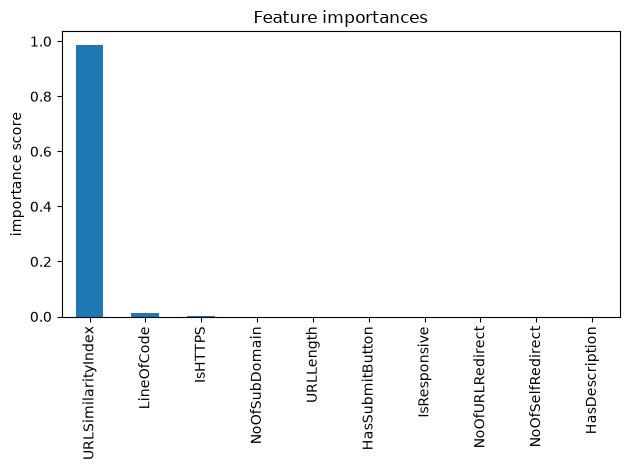

In [12]:
# identify the top 10 features the model used the most
import matplotlib.pyplot as plt # a tool for making charts

feature_importance = pd.Series(phishing_url_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print(feature_importance.head(10))

feature_importance.head(10).plot.bar()
plt.title("Feature importances")
plt.ylabel("importance score")
plt.tight_layout()
plt.show()


In [13]:
# drop the URLsimilarityIndex column
df = df.drop(columns=['URLSimilarityIndex'])
print(df.shape)


(235795, 50)


In [14]:
y = df['label']
X = df.drop(columns=["label"])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=1)
print(X_train.shape)
print(X_test.shape)

(188636, 49)
(47159, 49)


In [15]:
phishing_url_model = DecisionTreeClassifier(random_state=1)
phishing_url_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [16]:
predictions = phishing_url_model.predict(X_test)
accuracy_score(y_test, predictions)

0.9990245764329184

NoOfExternalRef               0.851107
NoOfSelfRef                   0.061039
NoOfOtherSpecialCharsInURL    0.027666
IsHTTPS                       0.015638
LineOfCode                    0.012022
NoOfSubDomain                 0.008999
HasSocialNet                  0.008390
NoOfImage                     0.004371
HasDescription                0.002697
CharContinuationRate          0.001430
dtype: float64


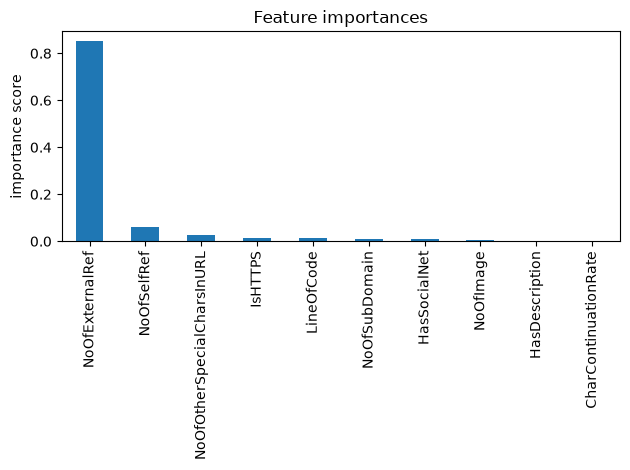

In [17]:
feature_importance = pd.Series(phishing_url_model.feature_importances_, index = X.columns).sort_values(ascending=False)
print(feature_importance.head(10))
feature_importance.head(10).plot.bar()
plt.title("Feature importances")
plt.ylabel("importance score")
plt.tight_layout()

In [18]:
df = df[['URLLength','DomainLength','IsDomainIP','TLDLegitimateProb','TLDLength','NoOfSubDomain','HasObfuscation','ObfuscationRatio','NoOfLettersInURL','LetterRatioInURL','NoOfDegitsInURL','DegitRatioInURL','NoOfEqualsInURL','NoOfQMarkInURL','NoOfAmpersandInURL','NoOfOtherSpecialCharsInURL','SpacialCharRatioInURL','IsHTTPS','Bank','Pay','Crypto','label']]
print(df.shape)

(235795, 22)


In [19]:
print(df.columns.tolist())

['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLegitimateProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'Bank', 'Pay', 'Crypto', 'label']


In [22]:
y = df['label']
X = df.drop(columns=['label'])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

print(X_test.shape)
print(X_train.shape)

(47159, 21)
(188636, 21)


In [23]:
phishing_url_model = DecisionTreeClassifier(random_state=1)
phishing_url_model.fit(X_train, y_train)

predictions = phishing_url_model.predict(X_test)
accuracy_score(y_test, predictions)

0.9966708369558303

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20215
           1       1.00      1.00      1.00     26944

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



NoOfOtherSpecialCharsInURL    0.476406
IsHTTPS                       0.373005
NoOfSubDomain                 0.062671
LetterRatioInURL              0.038801
DomainLength                  0.022338
NoOfDegitsInURL               0.010303
TLDLegitimateProb             0.004661
DegitRatioInURL               0.004526
SpacialCharRatioInURL         0.004118
NoOfLettersInURL              0.001449
dtype: float64


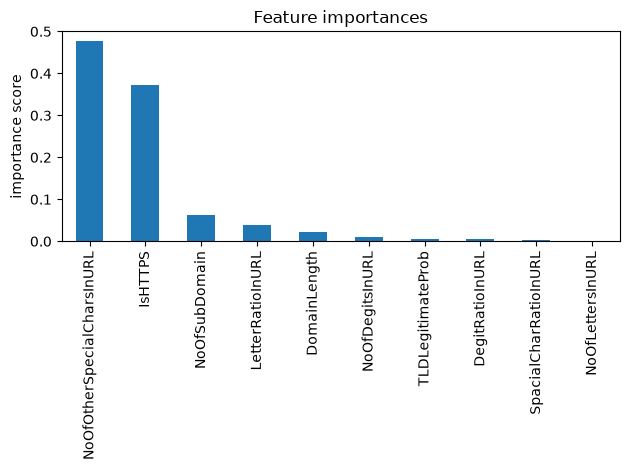

In [26]:
feature_importance = pd.Series(phishing_url_model.feature_importances_, index = X.columns).sort_values(ascending=False)
print(feature_importance.head(10))
feature_importance.head(10).plot.bar()
plt.title("Feature importances")
plt.ylabel("importance score")
plt.tight_layout()
